In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Dataset loaded successfully!
Number of samples: 150
Number of features: 4

First five rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Training samples: 120
Testing samples: 30

Starting GridSearchCV...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

GridSearchCV completed!

Best Hyperparameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}

Best Cross-Validation Accuracy:
0.9583333333333334

Best Random For

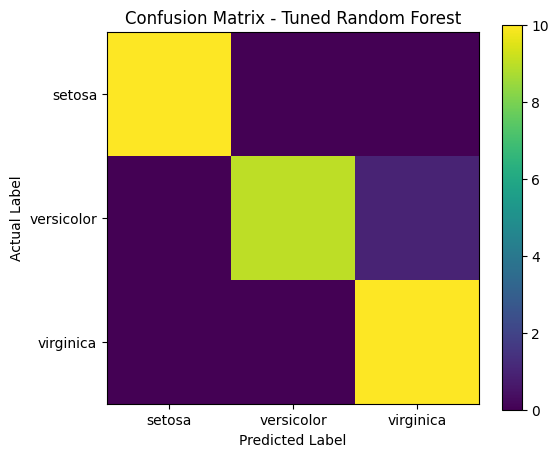


-----------------------------
FINAL RESULTS
-----------------------------
Best CV Accuracy: 0.9583333333333334
Test Accuracy: 0.9666666666666667
Test Precision: 0.9696969696969696
Test Recall: 0.9666666666666667


In [8]:
# --------------------------------------------------
# Hyperparameter Tuning using GridSearchCV
# Random Forest Classifier
# --------------------------------------------------

import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Load the dataset
# --------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])


# --------------------------------------------------
# 2. Convert dataset into DataFrame
# --------------------------------------------------

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

print("\nFirst five rows:")
print(df.head())


# --------------------------------------------------
# 3. Split dataset into training and testing data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# --------------------------------------------------
# 4. Create Random Forest model
# --------------------------------------------------

rf = RandomForestClassifier(
    random_state=42
)


# --------------------------------------------------
# 5. Define hyperparameter grid
# --------------------------------------------------

param_grid = {

    "n_estimators": [50, 100, 200],

    "max_depth": [None, 5, 10, 20],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]

}


# --------------------------------------------------
# 6. Create GridSearchCV
# --------------------------------------------------

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


# --------------------------------------------------
# 7. Perform hyperparameter tuning
# --------------------------------------------------

print("\nStarting GridSearchCV...")

grid_search.fit(X_train, y_train)

print("\nGridSearchCV completed!")


# --------------------------------------------------
# 8. Display best parameters
# --------------------------------------------------

print("\nBest Hyperparameters:")
print(grid_search.best_params_)


# --------------------------------------------------
# 9. Display best cross-validation score
# --------------------------------------------------

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)


# --------------------------------------------------
# 10. Get the best model
# --------------------------------------------------

best_model = grid_search.best_estimator_

print("\nBest Random Forest Model:")
print(best_model)


# --------------------------------------------------
# 11. Make predictions
# --------------------------------------------------

y_pred = best_model.predict(X_test)


# --------------------------------------------------
# 12. Calculate accuracy
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:")
print(accuracy)


# --------------------------------------------------
# 13. Calculate precision
# --------------------------------------------------

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nTest Precision:")
print(precision)


# --------------------------------------------------
# 14. Calculate recall
# --------------------------------------------------

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nTest Recall:")
print(recall)


# --------------------------------------------------
# 15. Classification report
# --------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


# --------------------------------------------------
# 16. Confusion matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# --------------------------------------------------
# 17. Display confusion matrix
# --------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Tuned Random Forest")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(3),
    iris.target_names
)

plt.yticks(
    range(3),
    iris.target_names
)

plt.colorbar()

plt.show()


# --------------------------------------------------
# 18. Compare CV accuracy with test accuracy
# --------------------------------------------------

print("\n-----------------------------")
print("FINAL RESULTS")
print("-----------------------------")

print(
    "Best CV Accuracy:",
    grid_search.best_score_
)

print(
    "Test Accuracy:",
    accuracy
)

print(
    "Test Precision:",
    precision
)

print(
    "Test Recall:",
    recall
)